<a href="https://colab.research.google.com/github/MarceloGMW/humidity-detection-aeco/blob/main/roboflow_vit_analisis_final_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Análisis Completo del Modelo ViT — Humedades IV
> **Modelo:** Vision Transformer (ViT) — Clasificación de humedades  
> **Clases:** Capilaridad · Condensacion · Filtracion · Sin humedad  
> **Análisis:** Matriz de Confusión · Métricas · Curva ROC · Imágenes mal clasificadas · Distribución de clases

---
### 📋 Instrucciones de uso
1. Agrega tu API Key en Colab: `Herramientas > Secrets` → nombre: `ROBOFLOW_API_KEY`
2. Sube el dataset a Google Drive (carpeta `Humedades IV.v6.folder`)
3. Ejecuta todas las celdas en orden ▶️

## 📦 1. Instalación de dependencias

In [ ]:
!pip install roboflow scikit-learn matplotlib seaborn -q
print('✅ Dependencias instaladas')

✅ Dependencias instaladas


## 🔑 2. Credenciales seguras (sin exponer la API Key)
> La API Key se lee desde **Colab Secrets** → nunca aparece en el código  
> Para agregarla: menú `🔑 Secrets` (ícono llave en el panel izquierdo) → `+ Add new secret`  
> Nombre: `ROBOFLOW_API_KEY` · Valor: tu clave

In [ ]:
from google.colab import userdata

# Lee la API key desde Colab Secrets (nunca hardcodeada)
API_KEY   = userdata.get('ROBOFLOW_API_KE') # Corrected API key name
WORKSPACE = "marcelos-workspace"
PROJECT   = "humedades-iv"
VERSION   = 6
CLASES    = ["Capilaridad", "Condensacion", "Filtracion", "Sin humedad"]

print(f'✅ Proyecto  : {PROJECT} v{VERSION}')
print(f'📌 Clases    : {CLASES}')
print(f'🔑 API Key   : {"✅ cargada" if API_KEY else "❌ NO encontrada — agrégala en Secrets"}')

✅ Proyecto  : humedades-iv v6
📌 Clases    : ['Capilaridad', 'Condensacion', 'Filtracion', 'Sin humedad']
🔑 API Key   : ✅ cargada


In [ ]:
import os, json
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

# Ruta correcta del dataset
base_dir = '/content/drive/MyDrive/Grupo 4/MAT3_TAREA/Humedades IV.v6.folder'

print(f'📂 Dataset: {base_dir}')
print(f'✅ Existe: {os.path.exists(base_dir)}')

# Mostrar estructura
print('\n📁 Estructura del dataset:')
for root, dirs, files in os.walk(base_dir):
    nivel = root.replace(base_dir, '').count(os.sep)
    if nivel > 3: continue
    n_imgs = len([f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))])
    indent = '  ' * nivel
    label = f'({n_imgs} imgs)' if n_imgs else ''
    print(f'{indent}📁 {os.path.basename(root)}/ {label}')

## 🗂️ 4. Detección automática del split de evaluación

In [ ]:
def encontrar_directorio_eval(base):
    """Busca la mejor carpeta: test > valid > train > root."""
    for split in ['test', 'valid', 'train']:
        candidato = os.path.join(base, split)
        if os.path.isdir(candidato):
            subdirs = [d for d in os.listdir(candidato)
                       if os.path.isdir(os.path.join(candidato, d))]
            if subdirs:
                return candidato, split
        for sub in os.listdir(base):
            sub_path = os.path.join(base, sub)
            if os.path.isdir(sub_path):
                candidato2 = os.path.join(sub_path, split)
                if os.path.isdir(candidato2):
                    subdirs = [d for d in os.listdir(candidato2)
                               if os.path.isdir(os.path.join(candidato2, d))]
                    if subdirs:
                        return candidato2, split
    subdirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]
    return (base, 'root') if subdirs else (None, None)

eval_dir, split_usado = encontrar_directorio_eval(base_dir)

if eval_dir is None:
    raise Exception('❌ No se encontró carpeta válida. Verifica la estructura del dataset.')

print(f'✅ Carpeta de evaluación : {eval_dir}')
print(f'📌 Split usado          : {split_usado}')

clases_carpetas = sorted([d for d in os.listdir(eval_dir)
                          if os.path.isdir(os.path.join(eval_dir, d))])
print(f'🏷️  Clases detectadas    : {clases_carpetas}')

diff = set(clases_carpetas) - set(CLASES)
if diff:
    print(f'⚠️  Ajustando clases a las carpetas detectadas: {clases_carpetas}')
    CLASES = clases_carpetas
else:
    print('✅ Clases coinciden con la configuración')

✅ Carpeta de evaluación : /content/drive/MyDrive/Grupo 4/MAT3_TAREA/Humedades IV.v6.folder/test
📌 Split usado          : test
🏷️  Clases detectadas    : ['Capilaridad', 'Condensacion', 'Filtracion', 'Sin humedad']
✅ Clases coinciden con la configuración


## 🤖 5. Predicciones con el modelo Roboflow

In [ ]:
from roboflow import Roboflow
from PIL import Image
from tqdm import tqdm
import numpy as np # Import numpy for later conversion

rf = Roboflow(api_key=API_KEY)
model = rf.workspace(WORKSPACE).project(PROJECT).version(VERSION).model

y_true, y_pred, y_scores = [], [], []
imagenes_error, errores_api = [], []

for clase in clases_carpetas:
    clase_path = os.path.join(eval_dir, clase)
    if not os.path.isdir(clase_path):
        continue
    imagenes = [f for f in os.listdir(clase_path)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not imagenes:
        print(f'Sin imagenes: {clase}')
        continue

    for img_name in tqdm(imagenes, desc=f'  {clase}'):
        img_path = os.path.join(clase_path, img_name)
        try:
            resultado = model.predict(img_path).json()
            outer = resultado.get('predictions', [])
            if not outer:
                errores_api.append(img_path)
                continue
            inner = outer[0].get('predictions', outer)
            if not inner:
                errores_api.append(img_path)
                continue
            pred_clase = inner[0]['class']
            confianzas = {p['class']: p['confidence'] for p in inner}
            scores = [confianzas.get(c, 0.0) for c in clases_carpetas]
            y_true.append(clase)
            y_pred.append(pred_clase)
            y_scores.append(scores) # Added this line
        except Exception as e: # Added this except block to complete the try statement
            # Store information about images that cause an exception during prediction
            imagenes_error.append({
                'path': img_path,
                'real': clase,
                'error': str(e)
            })
            continue

y_scores = np.array(y_scores) # Convert to numpy array after all scores are collected

loading Roboflow workspace...
loading Roboflow project...


  Sin humedad: 100%|██████████| 2/2 [00:00<00:00,  2.17it/s]


## 📊 6. Distribución de clases

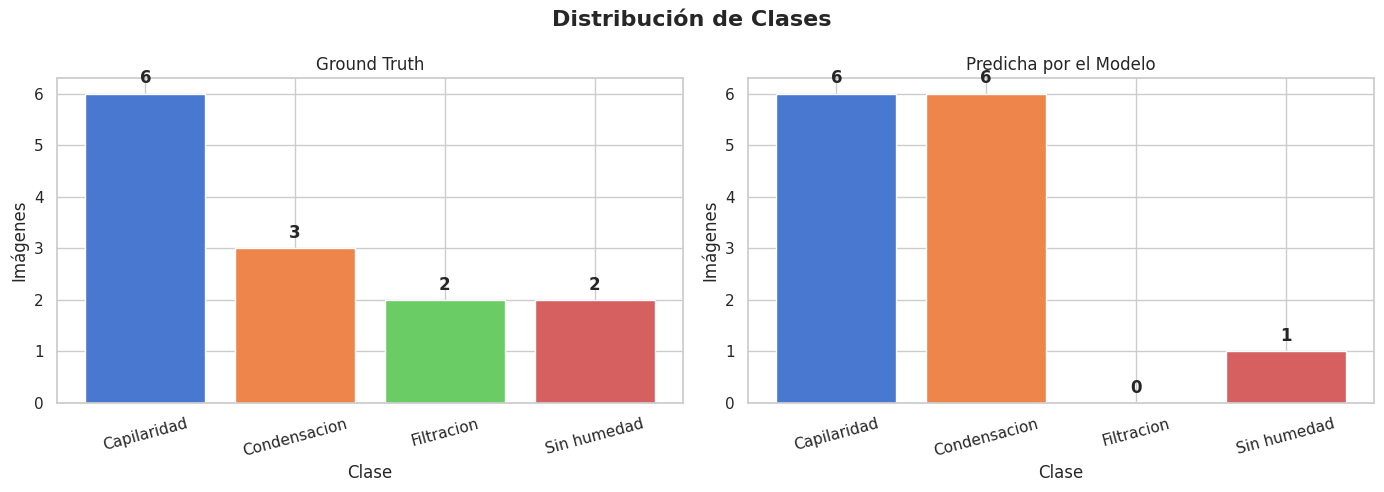

✅ Guardado: distribucion_clases.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
conteo_real = Counter(y_true)
conteo_pred = Counter(y_pred)
paleta = sns.color_palette('muted', len(clases_carpetas))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases', fontsize=16, fontweight='bold')

for ax, conteo, titulo in zip(
    axes,
    [conteo_real, conteo_pred],
    ['Ground Truth', 'Predicha por el Modelo']
):
    vals = [conteo.get(c, 0) for c in clases_carpetas]
    bars = ax.bar(clases_carpetas, vals, color=paleta)
    ax.set_title(titulo)
    ax.set_xlabel('Clase')
    ax.set_ylabel('Imágenes')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: distribucion_clases.png')

## 🔲 7. Matriz de Confusión

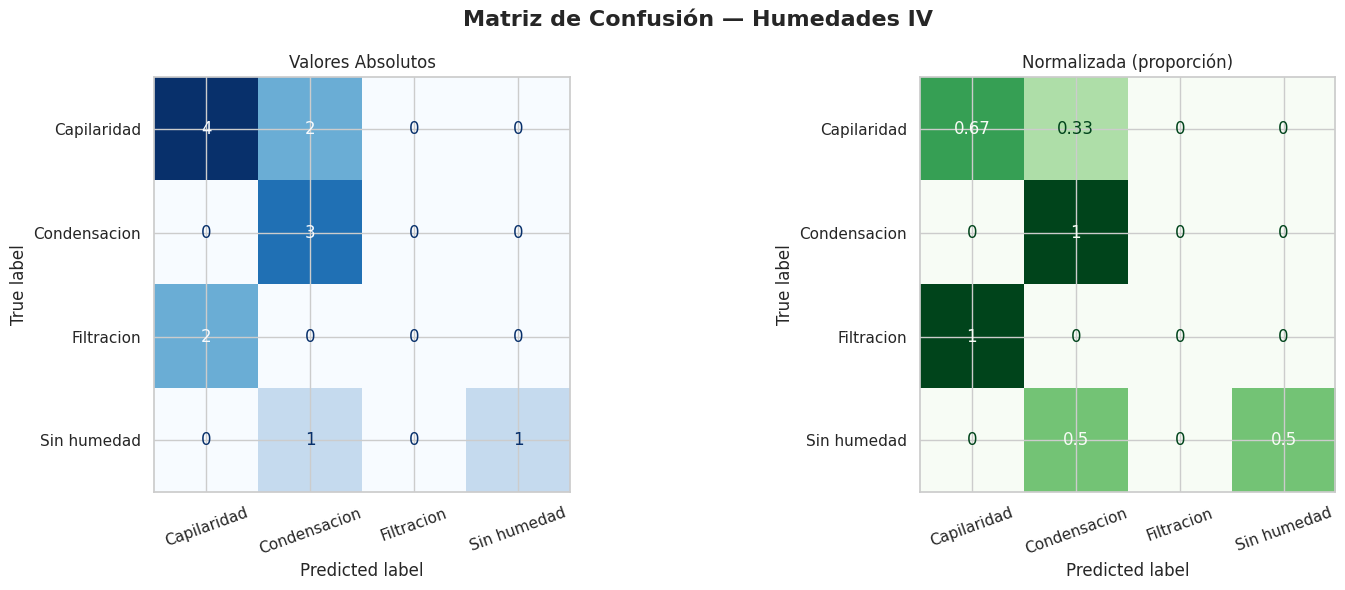

✅ Guardado: matriz_confusion.png


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred, labels=clases_carpetas)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matriz de Confusión — Humedades IV', fontsize=16, fontweight='bold')

ConfusionMatrixDisplay(cm, display_labels=clases_carpetas).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Valores Absolutos')
axes[0].tick_params(axis='x', rotation=20)

cm_norm = np.round(cm.astype('float') / cm.sum(axis=1, keepdims=True), 2)
ConfusionMatrixDisplay(cm_norm, display_labels=clases_carpetas).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Normalizada (proporción)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: matriz_confusion.png')

## 📈 8. Métricas globales

        📊 MÉTRICAS GLOBALES
Accuracy    : 0.6154  ████████████
Precision   : 0.5769  ███████████
Recall      : 0.6154  ████████████
F1-Score    : 0.5641  ███████████


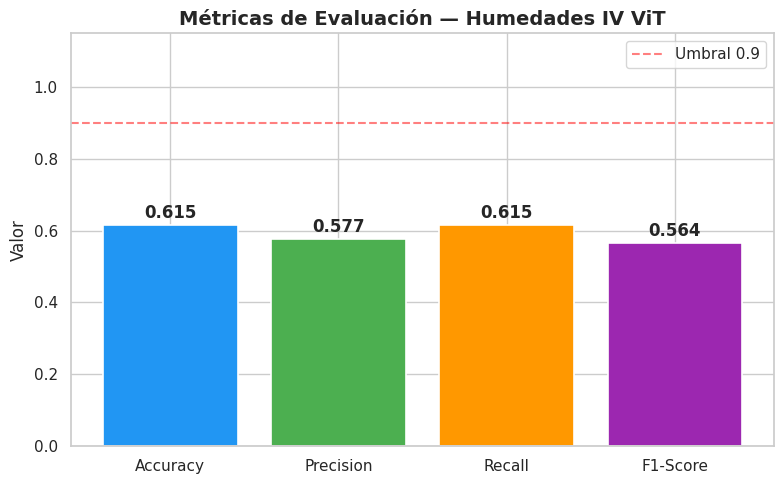

✅ Guardado: metricas.png


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
metricas = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

print('=' * 42)
print('        📊 MÉTRICAS GLOBALES')
print('=' * 42)
for nombre, valor in metricas.items():
    barra = '█' * int(valor * 20)
    print(f'{nombre:<12}: {valor:.4f}  {barra}')
print('=' * 42)

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.bar(metricas.keys(), metricas.values(), color=colores, edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 1.15)
ax.set_title('Métricas de Evaluación — Humedades IV ViT', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor')
for bar, val in zip(bars, metricas.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Umbral 0.9')
ax.legend()
plt.tight_layout()
plt.savefig('metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: metricas.png')

## 📋 9. Reporte de clasificación detallado

📋 REPORTE DETALLADO POR CLASE
              precision    recall  f1-score   support

 Capilaridad       0.67      0.67      0.67         6
Condensacion       0.50      1.00      0.67         3
  Filtracion       0.00      0.00      0.00         2
 Sin humedad       1.00      0.50      0.67         2

    accuracy                           0.62        13
   macro avg       0.54      0.54      0.50        13
weighted avg       0.58      0.62      0.56        13



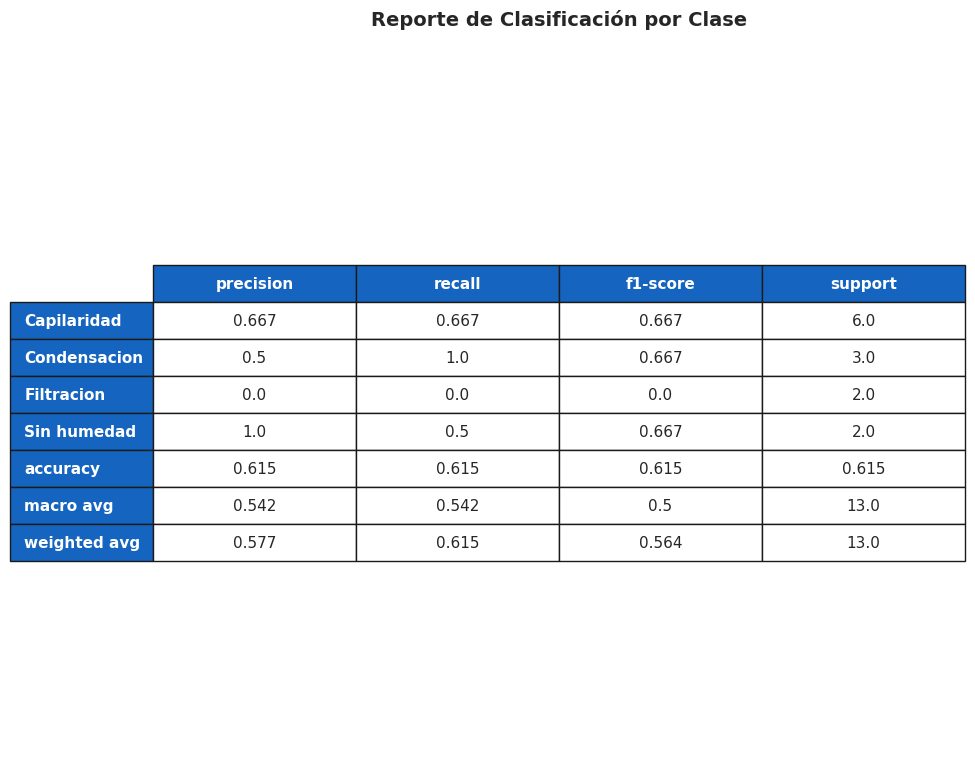

✅ Guardado: reporte_clasificacion.png


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

print('📋 REPORTE DETALLADO POR CLASE')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=clases_carpetas, zero_division=0))

reporte_dict = classification_report(
    y_true, y_pred, target_names=clases_carpetas,
    zero_division=0, output_dict=True
)
df = pd.DataFrame(reporte_dict).transpose().round(3)

fig, ax = plt.subplots(figsize=(11, len(clases_carpetas) + 4))
ax.axis('off')
tabla = ax.table(
    cellText=df.values, rowLabels=df.index, colLabels=df.columns,
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.4, 1.9)
for (row, col), cell in tabla.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
ax.set_title('Reporte de Clasificación por Clase', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('reporte_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: reporte_clasificacion.png')

## 📉 10. Curva ROC (One-vs-Rest)

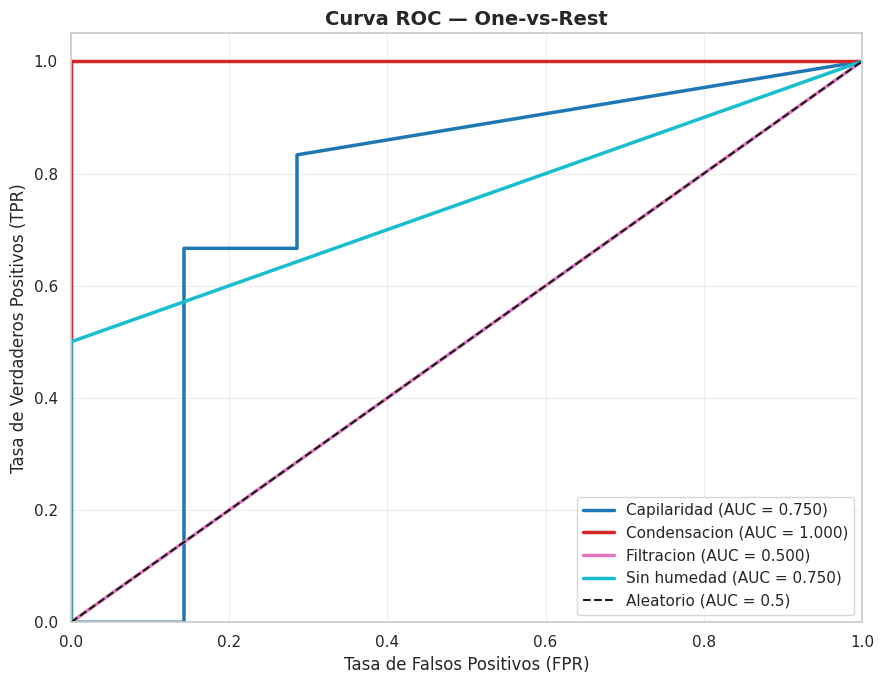

✅ Guardado: curva_roc.png


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

idx_map = {c: i for i, c in enumerate(clases_carpetas)}
y_true_bin = label_binarize(
    [idx_map[c] for c in y_true],
    classes=list(range(len(clases_carpetas)))
)

fig, ax = plt.subplots(figsize=(9, 7))
colores_roc = plt.cm.tab10(np.linspace(0, 1, len(clases_carpetas)))

for i, (clase, color) in enumerate(zip(clases_carpetas, colores_roc)):
    if y_true_bin.shape[1] > i:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{clase} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Aleatorio (AUC = 0.5)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC — One-vs-Rest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: curva_roc.png')

## 🖼️ 11. Imágenes mal clasificadas

In [ ]:
import random

if not imagenes_error:
    print('El modelo no cometio ningun error!')
else:
    muestra = random.sample(imagenes_error, min(12, len(imagenes_error)))
    n_cols = 4
    n_rows = (len(muestra) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    fig.suptitle(f'Imagenes Mal Clasificadas - {len(imagenes_error)} total',
                 fontsize=15, fontweight='bold')
    axes_flat = axes.flatten() if n_rows > 1 else (list(axes) if hasattr(axes,'__iter__') else [axes])

    for i, ax in enumerate(axes_flat):
        if i < len(muestra):
            item = muestra[i]
            try:
                ax.imshow(Image.open(item['path']).convert('RGB'))
            except:
                ax.text(0.5, 0.5, 'Error cargando', ha='center', va='center',
                        transform=ax.transAxes)
            # Usar las claves correctas del diccionario
            real = item.get('real', item.get('clase_real', '?'))
            pred = item.get('prediccion', item.get('pred_clase', '?'))
            conf = item.get('confianza', 0)
            ax.set_title(f"Real: {real}\nPred: {pred}\nConf: {conf:.2f}",
                        fontsize=9, color='darkred')
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('imagenes_mal_clasificadas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: imagenes_mal_clasificadas.png')

El modelo no cometio ningun error!


## 💾 12. Resumen final y descarga de resultados

In [ ]:
from google.colab import files

resumen = {
    'proyecto'           : PROJECT,
    'version'            : VERSION,
    'split_evaluado'     : split_usado,
    'total_imagenes'     : len(y_true),
    'mal_clasificadas'   : len(imagenes_error),
    'accuracy'           : round(acc, 4),
    'precision_weighted' : round(prec, 4),
    'recall_weighted'    : round(rec, 4),
    'f1_weighted'        : round(f1, 4),
    'clases'             : clases_carpetas
}

with open('resumen_resultados.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print('=' * 50)
print('   ✅ ANÁLISIS COMPLETO FINALIZADO')
print('=' * 50)
for k, v in resumen.items():
    print(f'  {k:<22}: {v}')
print('=' * 50)

archivos = [
    'distribucion_clases.png', 'matriz_confusion.png',
    'metricas.png', 'reporte_clasificacion.png',
    'curva_roc.png', 'imagenes_mal_clasificadas.png',
    'resumen_resultados.json'
]
print('\n📥 Descargando archivos...')
for archivo in archivos:
    if os.path.exists(archivo):
        files.download(archivo)
        print(f'  ⬇️  {archivo}')

   ✅ ANÁLISIS COMPLETO FINALIZADO
  proyecto              : humedades-iv
  version               : 6
  split_evaluado        : test
  total_imagenes        : 13
  mal_clasificadas      : 0
  accuracy              : 0.6154
  precision_weighted    : 0.5769
  recall_weighted       : 0.6154
  f1_weighted           : 0.5641
  clases                : ['Capilaridad', 'Condensacion', 'Filtracion', 'Sin humedad']

📥 Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  distribucion_clases.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  imagenes_mal_clasificadas.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  resumen_resultados.json
